# CNN classification with TorchVision

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True
plt.rcParams['figure.dpi'] = 150

In [2]:
# Check available hardware
import torch
if torch.cuda.is_available():
    print(f'GPU is available, using GPU {torch.cuda.get_device_name(0)}')
    device = torch.device('cuda')
elif torch.mps.is_available():
    print(f'Apple Metal Performance Shaders framework is available, using {torch.device("mps")}')
    device = torch.device('mps')
else:
    print(f'Hardware acceleration not available, using CPU')
    device = torch.device('cpu')

GPU is available, using GPU Tesla T4


## Dataset: STL10

In [3]:
import torch
import torchvision

# Set download=True if you haven't accessed this dataset before
img_train_val_dataset = torchvision.datasets.STL10(split='train', root='~/scr10/', download=False)
print(f'Train/val dataset has size {img_train_val_dataset.data.shape} and targets {img_train_val_dataset.labels.shape}')
print(f'Train/val dataset has {len(img_train_val_dataset.classes)} unique labels')

# Set download=True if you haven't accessed this dataset before
img_test_dataset = torchvision.datasets.STL10(split='test', root='~/scr10/', download=False)
print(f'Test dataset has size {img_test_dataset.data.shape} and targets {img_test_dataset.labels.shape}')
print(f'Test dataset has {len(img_test_dataset.classes)} unique labels')

Train/val dataset has size (5000, 3, 96, 96) and targets (5000,)
Train/val dataset has 10 unique labels
Test dataset has size (8000, 3, 96, 96) and targets (8000,)
Test dataset has 10 unique labels


### Visualization

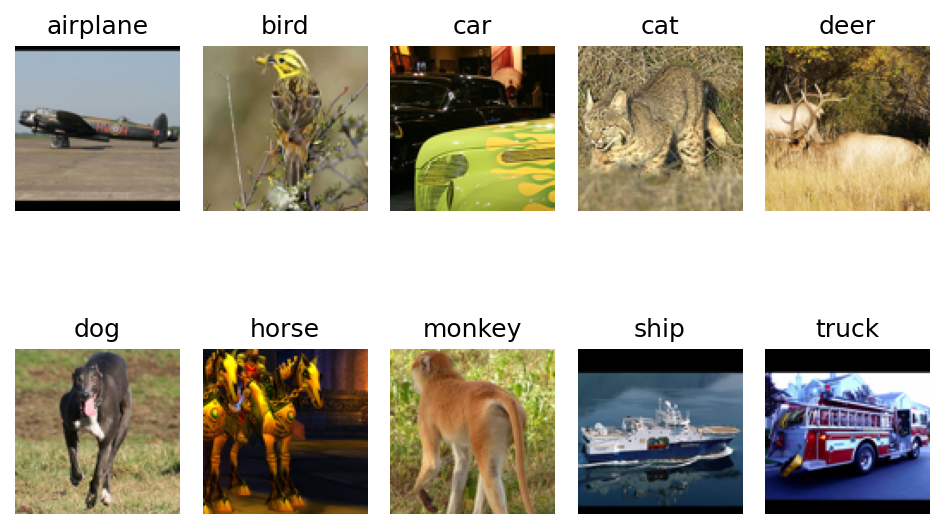

In [4]:
fig, ax = plt.subplots(2, 5, sharex=True, sharey=True)
ax = ax.flatten()
for ii in range(10):
    class_idx = np.argwhere(img_train_val_dataset.labels == ii)
    idx = class_idx[0,0]
    img, label = img_train_val_dataset[idx]
    ax[ii].imshow(img)
    ax[ii].axis('off')
    ax[ii].set_title(img_train_val_dataset.classes[ii])

plt.tight_layout()

## Torchvision models

See [here](https://docs.pytorch.org/vision/stable/models.html)

In [5]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT
resnet_model = resnet50(weights=weights)
resnet_model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [6]:
# These come with their own transforms
weights.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [7]:
from torch.utils.data import random_split

img_train_val_dataset.transform = weights.transforms()
img_train_dataset, img_val_dataset = random_split(img_train_val_dataset, lengths=[0.8, 0.2])
img_test_dataset.transform = weights.transforms()

x, y = img_train_dataset[0]
print(x.shape)

torch.Size([3, 224, 224])


In [8]:
# Let's perform some surgery
# Replace the classifier head in the ResNet model (1k classes from ImageNet)
# with a single numerical predictor
resnet_model.fc = nn.Identity() # Now this does nothing

# Freeze all weights in the resnet model
for param in resnet_model.parameters():
    param.requires_grad = False

classifier_head = nn.Linear(2048, 10)

model = nn.Sequential(
    resnet_model,
    classifier_head
)
model = model.to(device)
model(x[None].to(device)).shape

torch.Size([1, 10])

In [9]:
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'model has {num_trainable_params} trainable parameters')

model has 20490 trainable parameters


## CNN training

In [10]:
from tqdm.notebook import tqdm, trange
from torch.utils.data import DataLoader

def train(model, loss_fn, optimizer, train_dataset, val_dataset, 
          batch_size=32, num_epochs=100, num_workers=0, device=device):
    # Send model to correct hardware device
    model = model.to(device)

    # Create dataloaders for train/validation
    train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)

    train_loss, train_acc = [], []
    val_loss, val_acc = [], []
    
    for epoch in range(num_epochs):
        train_loss_ = 0.
        train_acc_ = 0.
        model.train()
        for x, y, in tqdm(train_loader, leave=False):
            # Send x, y to GPU/TPU/etc.
            x = x.to(device)
            y = y.to(device)

            # Make a prediction, compute the loss
            y_pred = model(x)
            loss = loss_fn(y_pred, y)

            # Backpropagate gradients, apply weight updates, reset gradients
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Logging
            train_loss_ += loss.item() * x.shape[0]
            train_acc_  += (torch.argmax(y_pred, dim=1) == y).float().sum().item()

        train_loss.append(train_loss_ / len(train_dataset))
        train_acc.append(train_acc_ / len(train_dataset))

        val_loss_ = 0.
        val_acc_ = 0.
        model.eval()
        with torch.no_grad():
            for x, y, in tqdm(val_loader, leave=False):
                # Send x, y to GPU/TPU/etc.
                x = x.to(device)
                y = y.to(device)
    
                # Make a prediction, compute the loss
                y_pred = model(x)
                loss = loss_fn(y_pred, y)
        
                # Logging
                val_loss_ += loss.item() * x.shape[0]
                val_acc_  += (torch.argmax(y_pred, dim=1) == y).float().sum().item()

            val_loss.append(val_loss_ / len(val_dataset))
            val_acc.append(val_acc_ / len(val_dataset))

        print(f'Epoch {epoch+1} | '
              f'Train loss { train_loss[-1]:.3f} | '
              f'Train acc { train_acc[-1]:.3f} | '
              f'Val loss { val_loss[-1]:.3f} | '
              f'Val acc { val_acc[-1]:.3f}'
        )

    return model, (train_loss, train_acc, val_loss, val_acc)

In [11]:
# Define a loss function and optimizer
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model, model_stats = train(
    model, 
    loss, 
    optimizer, 
    img_train_dataset, 
    img_val_dataset, 
    num_epochs=5,
    batch_size=64,
    num_workers=4,
)

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1 | Train loss 1.031 | Train acc 0.844 | Val loss 0.469 | Val acc 0.941


  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

...

  0%|          | 0/16 [00:00<?, ?it/s]

Epoch 4 | Train loss 0.148 | Train acc 0.977 | Val loss 0.176 | Val acc 0.961


  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

Epoch 5 | Train loss 0.117 | Train acc 0.980 | Val loss 0.158 | Val acc 0.960


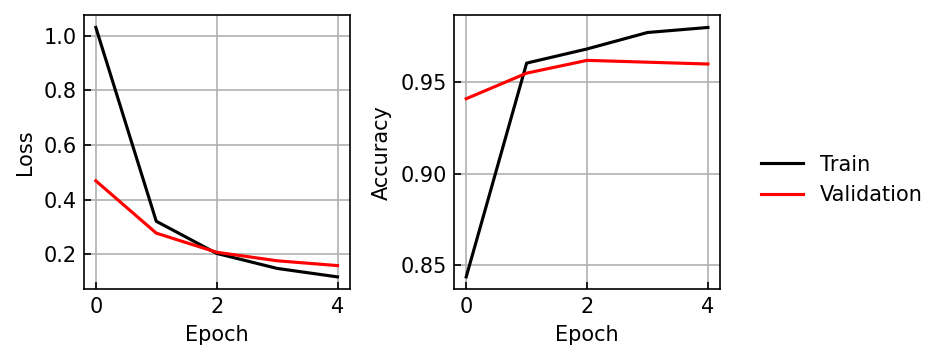

In [12]:
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(5, 2.5))

train_loss, train_acc, val_loss, val_acc = model_stats
ax[0].plot(train_loss, color='black', label='Train')
ax[0].plot(val_loss, color='red', label='Validation')
ax[0].set(xlabel='Epoch', ylabel='Loss')

ax[1].plot(train_acc, color='black', label='Train')
ax[1].plot(val_acc, color='red', label='Validation')
ax[1].set(xlabel='Epoch', ylabel='Accuracy')

fig.legend(*ax[1].get_legend_handles_labels(), 
           loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)

plt.tight_layout()

## Model inference

In [14]:
# Inference
model.eval()
test_loader = DataLoader(img_test_dataset, batch_size=32, shuffle=False, num_workers=4)
with torch.no_grad():
    test_correct_ = 0.
    for xb, yb in tqdm(test_loader,leave=False):
        xb = xb.to(device)
        yb = yb.to(device)
        y_pred = model(xb)
        y_pred = torch.argmax(y_pred, dim=1)
        test_correct_ += (y_pred == yb).float().sum().item()
    test_acc = test_correct_ / len(test_loader.dataset)

print(f"Test accuracy: {test_acc:.3f}")

  0%|          | 0/250 [00:00<?, ?it/s]

Test accuracy: 0.965


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


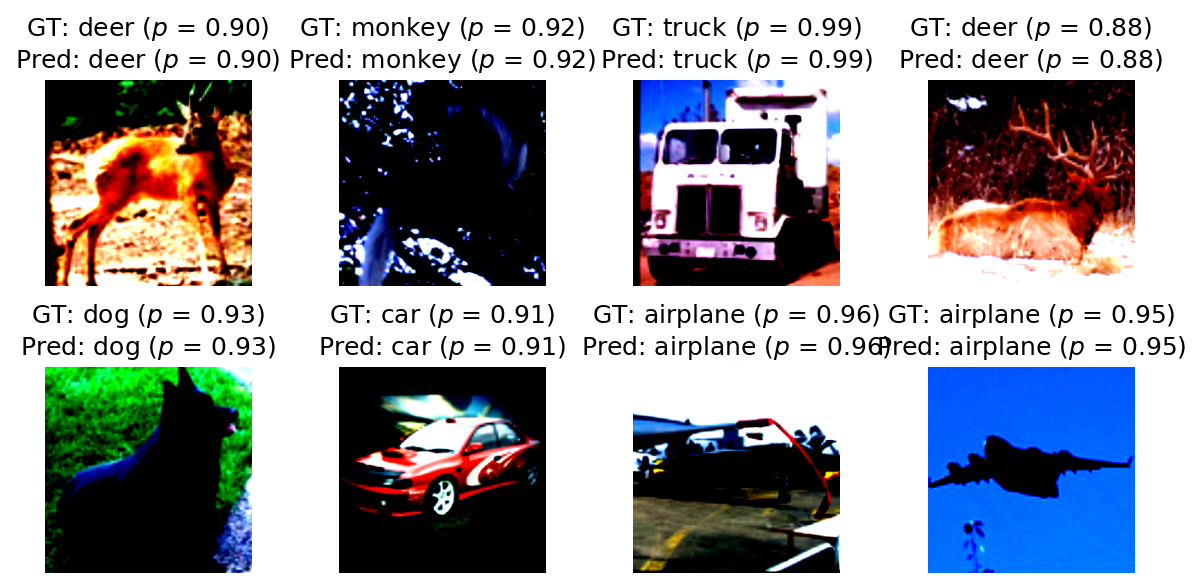

In [15]:
# Look at 8 examples
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
with torch.no_grad():
    xb = xb.to(device)
    y_pred = model(xb)
    y_pred = F.softmax(y_pred, dim=1)
    y_pred = y_pred.cpu().numpy()
for ax, img, label, pred in zip(axes.flatten(), xb, yb, y_pred):
    corr_prob = pred[label]
    pred_prob = pred.max()
    pred_label = np.argmax(pred)
    ax.imshow(img.permute(1, 2, 0).cpu())
    ax.set_title(
        f'GT: {img_test_dataset.classes[label]} ($p$ = {corr_prob:.2f})\n'
        f'Pred: {img_test_dataset.classes[pred_label]} ($p$ = {pred_prob:.2f})')
    ax.axis('off')

plt.tight_layout()